# BERT for Sentiment Analysis on IMDb Reviews

**Deep Learning Laboratory — Professional Implementation**

### Assignment
> Implement a pre-trained BERT model for sentiment analysis or text classification on a sample dataset.

### Objective
Fine-tune the pre-trained **BERT-base-uncased** model for binary sentiment classification of IMDb movie reviews.

### Learning outcomes
- Understand transfer learning with Transformer models.
- Load and inspect a real-world text classification dataset.
- Tokenize natural-language text using a BERT tokenizer.
- Fine-tune a pre-trained BERT model.
- Evaluate a text classifier using accuracy, precision, recall and F1-score.
- Visualize the confusion matrix and training history.
- Perform inference on custom text.

**Dataset:** IMDb Movie Reviews  
**Classes:** Negative (0), Positive (1)  
**Base model:** `bert-base-uncased`

## 1. Background: Why BERT?

BERT (Bidirectional Encoder Representations from Transformers) is a Transformer-based language model pre-trained on large amounts of text.

Instead of training a language model from scratch for every NLP problem, we can reuse the linguistic representations learned during pre-training and **fine-tune** the model for a downstream task such as sentiment analysis.

### Workflow

```text
IMDb Reviews
      ↓
BERT Tokenizer
      ↓
Token IDs + Attention Masks
      ↓
Pre-trained BERT
      ↓
Classification Head
      ↓
Fine-tuning
      ↓
Positive / Negative
```

For this experiment, BERT is loaded with a new two-class classification head and trained on labeled IMDb reviews.

In [1]:
# 2. Install dependencies
# Run this cell once in a fresh environment.

# %pip install -q "torch>=2.2" "transformers>=4.40,<6" "datasets>=2.18" "scikit-learn>=1.3" "matplotlib>=3.7" "seaborn>=0.13" "pandas>=2.0" "numpy>=1.24" "tqdm>=4.66"

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch: 2.14.0+cu130
CUDA available: True
CUDA version: 13.0
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU count: 1


In [3]:
# 3. Imports and reproducibility

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/home/rohan/DL_Projects/.dl_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.14.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 4. Load the IMDb Dataset

The IMDb dataset contains movie reviews labeled as positive or negative.

For this lab, a configurable subset is used so the experiment remains practical on student hardware. The same code can be scaled to the complete dataset later.

In [4]:
# Dataset configuration

TRAIN_SAMPLES = 8000
VAL_SAMPLES = 2000
TEST_SAMPLES = 2000

MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

MODEL_NAME = "bert-base-uncased"

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)
print("\nTrain examples:", len(dataset["train"]))
print("Test examples :", len(dataset["test"]))

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train examples: 25000
Test examples : 25000


In [5]:
# 5. Create train / validation / test subsets

train_full = dataset["train"].shuffle(seed=SEED)
test_full = dataset["test"].shuffle(seed=SEED)

train_ds = train_full.select(range(min(TRAIN_SAMPLES, len(train_full))))
val_ds = train_full.select(
    range(TRAIN_SAMPLES, min(TRAIN_SAMPLES + VAL_SAMPLES, len(train_full)))
)
test_ds = test_full.select(range(min(TEST_SAMPLES, len(test_full))))

print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))

Train size: 8000
Validation size: 2000
Test size: 2000


{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...', 'label': 1}

Label mapping: 0 = Negative, 1 = Positive


,count
Negative,3988
Positive,4012


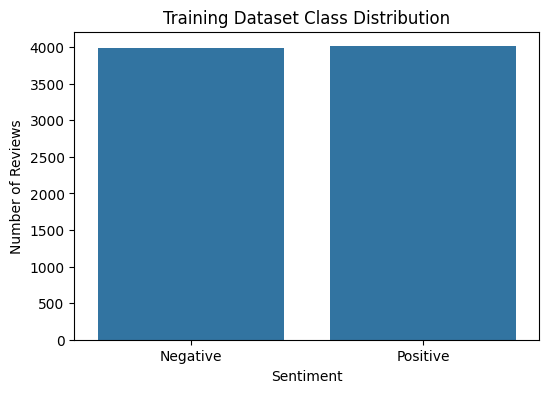

In [6]:
# 6. Explore the dataset

print(train_ds[0])
print("\nLabel mapping: 0 = Negative, 1 = Positive")

label_counts = pd.Series(train_ds["label"]).value_counts().sort_index()
label_counts.index = ["Negative", "Positive"]

display(label_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Training Dataset Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

Average words: 233.12225
Median words : 174.0
Maximum words: 1839


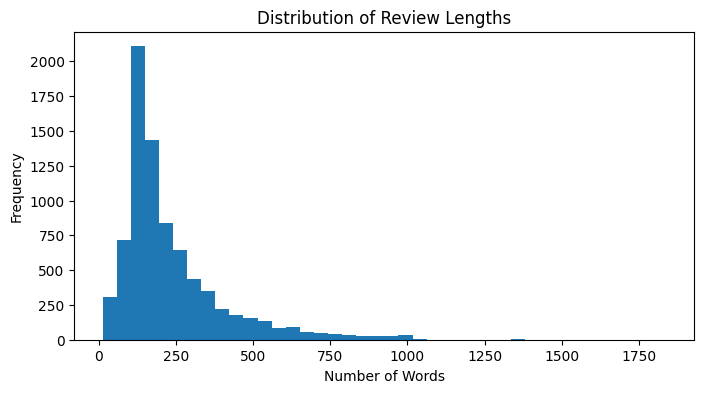

In [7]:
# 7. Inspect review lengths

lengths = [len(text.split()) for text in train_ds["text"]]

print("Average words:", np.mean(lengths))
print("Median words :", np.median(lengths))
print("Maximum words:", np.max(lengths))

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=40)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## 5. BERT Tokenization

BERT does not directly consume raw strings. The tokenizer converts text into:

- `input_ids`: numerical token IDs
- `attention_mask`: identifies real tokens versus padding
- `token_type_ids`: segment information used by BERT when applicable

Long reviews are truncated to `MAX_LENGTH=256` tokens for this experiment.

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_text = train_ds[0]["text"]
encoded_sample = tokenizer(
    sample_text,
    truncation=True,
    max_length=MAX_LENGTH
)

print("Original text:")
print(sample_text[:500], "...")
print("\nToken IDs:", encoded_sample["input_ids"][:20])
print("Number of tokens:", len(encoded_sample["input_ids"]))

Original text:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks Am ...

Token IDs: [101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610]
Number of tokens: 179


In [9]:
# 8. Tokenize the complete datasets

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok = val_ds.map(tokenize_batch, batched=True)
test_tok = test_ds.map(tokenize_batch, batched=True)

print(train_tok.column_names)

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## 6. Prepare PyTorch DataLoaders

Dynamic padding is used through `DataCollatorWithPadding`. This avoids padding every review to the maximum sequence length before batching and is generally more efficient.

In [10]:
from transformers import DataCollatorWithPadding
from torch.utils.data import DataLoader

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Keep only model inputs and labels.
model_columns = ["input_ids", "attention_mask", "label"]
if "token_type_ids" in train_tok.column_names:
    model_columns.insert(2, "token_type_ids")

train_tok.set_format("torch", columns=model_columns)
val_tok.set_format("torch", columns=model_columns)
test_tok.set_format("torch", columns=model_columns)

train_loader = DataLoader(
    train_tok,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)

val_loader = DataLoader(
    val_tok,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

test_loader = DataLoader(
    test_tok,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 1000
Validation batches: 250
Test batches: 250


## 7. Load the Pre-trained BERT Model

`AutoModelForSequenceClassification` adds a classification head on top of BERT.

The output contains two logits:

```text
logit 0 → Negative
logit 1 → Positive
```

The complete model is then fine-tuned using the IMDb labels.

In [11]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 661.77it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

Total parameters    : 109,483,778
Trainable parameters: 109,483,778


## 8. Fine-tuning Configuration

Typical BERT fine-tuning settings use a small learning rate because the model already contains useful pre-trained representations.

For this lab:

- Optimizer: AdamW
- Learning rate: `2e-5`
- Weight decay: `0.01`
- Epochs: `2`
- Gradient clipping: `1.0`
- Linear learning-rate scheduler with warm-up

In [12]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("Total training steps:", total_training_steps)
print("Warm-up steps:", warmup_steps)

Total training steps: 2000
Warm-up steps: 200


In [13]:
# 9. Evaluation function

def evaluate_model(model, loader):
    model.eval()

    all_predictions = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)

            total_loss += outputs.loss.item()

            predictions = outputs.logits.argmax(dim=-1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="binary",
        zero_division=0
    )

    return {
        "loss": total_loss / max(len(loader), 1),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_predictions
    }

In [14]:
# 10. Fine-tune BERT

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": []
}

best_f1 = -1.0
OUTPUT_DIR = "outputs/bert-imdb"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for batch in progress:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / len(train_loader)

    val_metrics = evaluate_model(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss={train_loss:.4f}, "
        f"Val Loss={val_metrics['loss']:.4f}, "
        f"Val Accuracy={val_metrics['accuracy']:.4f}, "
        f"Val F1={val_metrics['f1']:.4f}"
    )

    # Save the best validation checkpoint.
    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]

        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)

        print("Best model checkpoint saved.")

Epoch 1/2: 100%|██████████| 1000/1000 [04:06<00:00,  4.06it/s, loss=0.7726]


Epoch 1: Train Loss=0.3860, Val Loss=0.4312, Val Accuracy=0.8750, Val F1=0.8823


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


Best model checkpoint saved.


Epoch 2/2: 100%|██████████| 1000/1000 [04:05<00:00,  4.07it/s, loss=0.0124]


Epoch 2: Train Loss=0.2209, Val Loss=0.3728, Val Accuracy=0.9055, Val F1=0.9040


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]

Best model checkpoint saved.


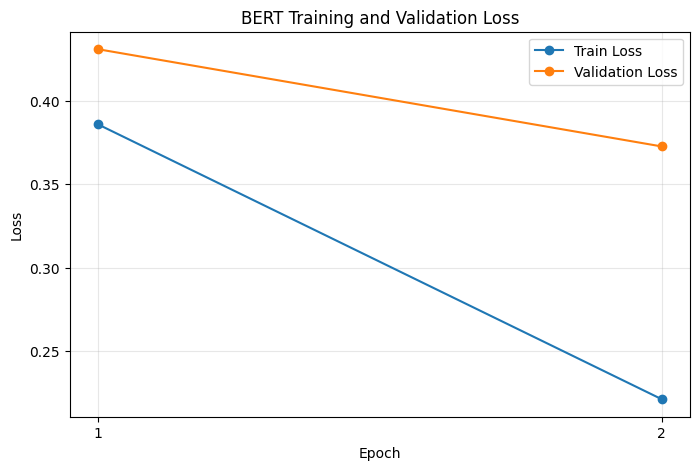

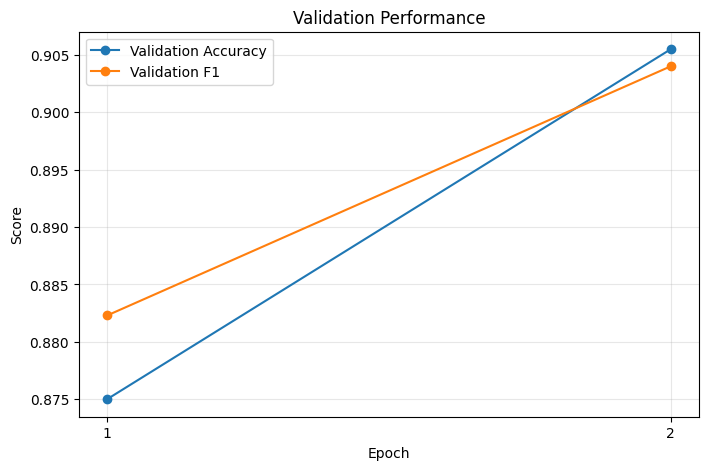

In [15]:
# 11. Plot training history

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(epochs_range, history["val_f1"], marker="o", label="Validation F1")
plt.title("Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Final Test Evaluation

The best validation checkpoint is reloaded before evaluating the unseen test set.

The main metrics are:

- **Accuracy:** proportion of correctly classified reviews.
- **Precision:** proportion of predicted positive reviews that are actually positive.
- **Recall:** proportion of actual positive reviews correctly identified.
- **F1-score:** harmonic mean of precision and recall.

In [16]:
# 12. Load best model and evaluate on the test set

best_model = AutoModelForSequenceClassification.from_pretrained(
    OUTPUT_DIR
).to(device)

test_metrics = evaluate_model(best_model, test_loader)

print("Final Test Results")
print("-" * 40)
print(f"Accuracy : {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall   : {test_metrics['recall']:.4f}")
print(f"F1-score : {test_metrics['f1']:.4f}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3040.07it/s]


Final Test Results
----------------------------------------
Accuracy : 0.9110
Precision: 0.9177
Recall   : 0.9030
F1-score : 0.9103


In [17]:
# 13. Classification report

print(
    classification_report(
        test_metrics["labels"],
        test_metrics["predictions"],
        target_names=["Negative", "Positive"],
        digits=4
    )
)

              precision    recall  f1-score   support

    Negative     0.9045    0.9190    0.9117      1000
    Positive     0.9177    0.9030    0.9103      1000

    accuracy                         0.9110      2000
   macro avg     0.9111    0.9110    0.9110      2000
weighted avg     0.9111    0.9110    0.9110      2000



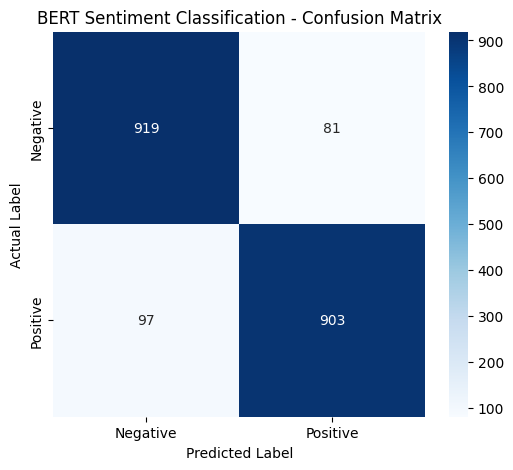

In [18]:
# 14. Confusion matrix

cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["predictions"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("BERT Sentiment Classification - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## 10. Custom Sentiment Prediction

The fine-tuned model can now be used on previously unseen text.

The prediction is obtained from the softmax probabilities of the two classification logits.

In [ ]:
# 15. Prediction helper

def predict_sentiment(text):
    best_model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = best_model(**inputs).logits
        probabilities = torch.softmax(logits, dim=-1)[0]

    predicted_id = probabilities.argmax().item()
    label = best_model.config.id2label[predicted_id]
    confidence = probabilities[predicted_id].item()

    return label, confidence


examples = [
    "The movie was fantastic, emotional, and beautifully acted.",
    "The story was boring and the acting was disappointing.",
    "A surprisingly good movie with excellent performances."
]

for review in examples:
    label, confidence = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Prediction: {label} | Confidence: {confidence:.4f}")
    print("-" * 80)

Review: The movie was fantastic, emotional, and beautifully acted.
Prediction: POSITIVE | Confidence: 0.9974
--------------------------------------------------------------------------------
Review: The story was boring and the acting was disappointing.
Prediction: NEGATIVE | Confidence: 0.9962
--------------------------------------------------------------------------------
Review: A surprisingly good movie with excellent performances.
Prediction: POSITIVE | Confidence: 0.9971
--------------------------------------------------------------------------------


: 

## 11. Conclusion

The pre-trained **BERT-base-uncased** model was successfully fine-tuned for binary sentiment classification using the IMDb movie-review dataset. The experiment demonstrated the complete NLP transfer-learning workflow: dataset preparation, BERT tokenization, model fine-tuning, validation, test evaluation, confusion-matrix analysis, and prediction on custom text.

The final performance should be reported using the **actual values produced by the experiment** for accuracy, precision, recall, and F1-score. The confusion matrix provides additional insight into positive and negative classification errors.

### Key observations
1. Pre-trained BERT provides strong contextual representations for natural-language text.
2. Fine-tuning adapts these representations to the sentiment-classification task.
3. A small learning rate is appropriate when fine-tuning a pre-trained Transformer.
4. Accuracy alone is not sufficient; precision, recall, F1-score, and the confusion matrix provide a more complete evaluation.
5. The trained model can be reused for inference on new movie-review text.

### Possible extensions
- Train on the complete IMDb training set.
- Compare BERT with DistilBERT or RoBERTa.
- Experiment with sequence lengths of 128, 256, and 512.
- Compare different learning rates and batch sizes.
- Deploy the model through a FastAPI or Streamlit application.

## References

1. Hugging Face Transformers — Text Classification:
   https://huggingface.co/docs/transformers/main/tasks/sequence_classification

2. IMDb dataset on Hugging Face:
   https://huggingface.co/datasets/stanfordnlp/imdb

3. Devlin et al. — *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*.